#Práctica 3: **Clasificador por distancia euclidiana**


Integrantes:

*   Aguirre Lanto Victor Manuel
*   Gasca Fragoso Pedro
*   Guevara Badillo Areli Alejandra
*   Montiel Toro Arael de Jesús
*   Ramirez Lozano Gael Martin



#Bibliotecas necesarias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score

#Conjunto de datos de ejemplo

In [ ]:
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2,
                          n_clusters_per_class=1, n_redundant=0, random_state=42)


División del conjunto de datos en entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Gráfica del Entrenamiento y pruebas

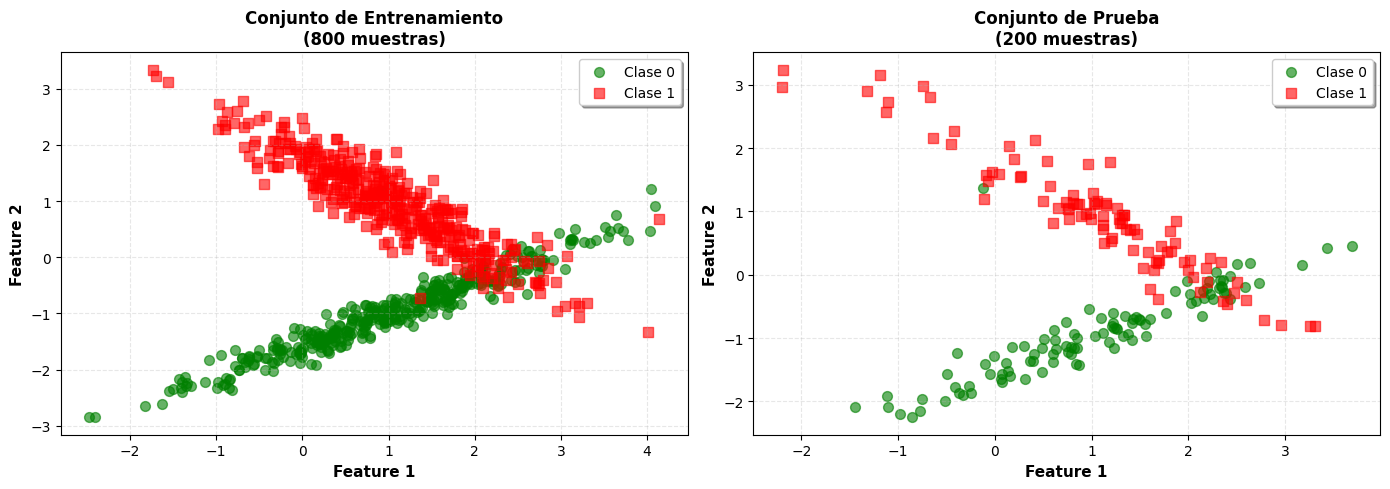


INFORMACIÓN DE LOS CONJUNTOS
Ejemplo de X_train:
 [[ 1.469818    0.5287991 ]
 [ 0.69413954 -1.06876393]
 [ 1.75247488  0.1976829 ]
 [-1.34223747 -2.24262299]
 [ 1.64485452 -0.59142627]]
Ejemplo de X_test:
 [[ 1.19925595  0.52980118]
 [-0.7544068  -1.95743847]
 [ 0.96842043 -0.54096984]
 [ 0.31499184 -1.64808794]
 [-1.11342844 -1.91877162]]
Ejemplo de y_train:
 [1 0 1 0 0]
Ejemplo de y_test:
 [1 0 0 0 0]


In [ ]:
# Colorear los puntos de entrenamiento y prueba con diferentes marcadores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del conjunto de entrenamiento
axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
               c='green', marker='o', label='Clase 0', alpha=0.6, edgecolors='green', s=50)
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
               c='red', marker='s', label='Clase 1', alpha=0.6, edgecolors='red', s=50)
axes[0].set_xlabel('Feature 1', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=11, fontweight='bold')
axes[0].set_title(f'Conjunto de Entrenamiento\n({len(X_train)} muestras)',
                 fontsize=12, fontweight='bold')
axes[0].legend(loc='best', frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Gráfico del conjunto de prueba
axes[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
               c='green', marker='o', label='Clase 0', alpha=0.6, edgecolors='green', s=50)
axes[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
               c='red', marker='s', label='Clase 1', alpha=0.6, edgecolors='red', s=50)
axes[1].set_xlabel('Feature 1', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Feature 2', fontsize=11, fontweight='bold')
axes[1].set_title(f'Conjunto de Prueba\n({len(X_test)} muestras)',
                 fontsize=12, fontweight='bold')
axes[1].legend(loc='best', frameon=True, shadow=True)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Mostrar una parte de los datos de entrenamiento y prueba
print("\n" + "="*60)
print("INFORMACIÓN DE LOS CONJUNTOS")
print("="*60)
print("Ejemplo de X_train:\n", X_train[:5])
print("Ejemplo de X_test:\n", X_test[:5])
print("Ejemplo de y_train:\n", y_train[:5])
print("Ejemplo de y_test:\n", y_test[:5])

3. Implementación de la función de distancia euclidiana

In [ ]:
def euclidean_distance(point1, point2):
    # Convierte los puntos a arrays de numpy para operaciones vectorizadas
    point1 = np.array(point1)
    point2 = np.array(point2)

    # Calcula la diferencia entre coordenadas
    differences = point1 - point2

    # Eleva al cuadrado cada diferencia
    squared_differences = differences ** 2

    # Suma todos los cuadrados
    sum_of_squares = np.sum(squared_differences)

    # Calcula la raíz cuadrada
    distance = np.sqrt(sum_of_squares)

    return distance

# Probar la función
punto_a = [1, 2]
punto_b = [4, 6]
distancia = euclidean_distance(punto_a, punto_b)
print(f"Distancia entre {punto_a} y {punto_b}: {distancia:.4f}")

Distancia entre [1, 2] y [4, 6]: 5.0000


#Cómo Funciona
Calcula la distancia euclidiana entre dos puntos.

    Parámetros:
    - point1: array, primer punto (vector de características)
    - point2: array, segundo punto (vector de características)
    
    Retorna:
    - float: distancia euclidiana entre los dos puntos
    
    Fórmula: d = sqrt((x1-x2)^2 + (y1-y2)^2 + ... + (xn-yn)^2)

4. Implementar la función de clasificación por distancia euclidiana

In [ ]:
def euclidean_classifier(train_data, train_labels, test_point):
    # Calcula las distancias del test_point a todos los puntos de entrenamiento
    # Itera sobre cada punto en train_data y calcula su distancia al test_point
    distances = [euclidean_distance(train_point, test_point) for train_point in train_data]

    # Encuentra el índice del vecino más cercano (distancia mínima)
    # np.argmin retorna el índice del valor mínimo en el array distances
    nearest_neighbor_index = np.argmin(distances)

    # Retorna la etiqueta del vecino más cercano
    # Usa el índice encontrado para acceder a la etiqueta correspondiente
    return train_labels[nearest_neighbor_index]

# Probar con un punto del conjunto de prueba
punto_prueba = X_test[0]
prediccion = euclidean_classifier(X_train, y_train, punto_prueba)
print(f"Punto de prueba: {punto_prueba}")
print(f"Predicción: {prediccion}")
print(f"Etiqueta real: {y_test[0]}")


Punto de prueba: [1.19925595 0.52980118]
Predicción: 1
Etiqueta real: 1


#Cómo Funciona
Clasifica un punto de prueba usando el algoritmo 1-NN (vecino más cercano).
    
    Parámetros:
    - train_data: array de forma (n_samples, n_features), datos de entrenamiento
    - train_labels: array de forma (n_samples,), etiquetas de entrenamiento
    - test_point: array de forma (n_features,), punto a clasificar
    
    Retorna:
    - int: clase predicha para el punto de prueba
    
    Funcionamiento:
    1. Calcula la distancia del test_point a todos los puntos de entrenamiento
    2. Encuentra el punto de entrenamiento más cercano (distancia mínima)
    3. Retorna la etiqueta de ese vecino más cercano

#5. Clasificar el conjunto de prueba y evaluar la precisión

In [ ]:
# Clasificar todos los puntos del conjunto de prueba
predictions = [euclidean_classifier(X_train, y_train, test_point) for test_point in X_test]

# Calcular la precisión (accuracy)
accuracy = accuracy_score(y_test, predictions)

print(f"Precisión del clasificador: {accuracy * 100:.2f}%")

Precisión del clasificador: 90.50%


Métricas recall y F1 – F-score.

In [ ]:
# Calcular recall y F1-score
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("MÉTRICAS DE EVALUACIÓN")
print("="*60)
print(f"Precisión del clasificador: {accuracy * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-Score: {f1 * 100:.2f}%")

MÉTRICAS DE EVALUACIÓN
Precisión del clasificador: 90.50%
Recall: 93.75%
F1-Score: 90.45%


Modificación de parámetros

In [ ]:
print("EXPERIMENTACIÓN CON DIFERENTES PARÁMETROS")
print("="*60)

# EXPERIMENTO 1: Variando n_samples (número de muestras)
print("\n1. Variando n_samples (número de muestras):")
print("-" * 80)
sample_sizes = [100, 500, 1000, 2000]
for n_samples in sample_sizes:
    X_exp, y_exp = make_classification(n_samples=n_samples, n_features=2,
                                       n_classes=2, n_clusters_per_class=1,
                                       n_redundant=0, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)
    preds = [euclidean_classifier(X_tr, y_tr, tp) for tp in X_te]
    acc = accuracy_score(y_te, preds)
    rec = recall_score(y_te, preds)
    f1 = f1_score(y_te, preds)
    print(f"  n_samples={n_samples:4d} -> Precisión: {acc*100:.2f}%, Recall: {rec*100:.2f}%, F1-Score: {f1*100:.2f}%")

# EXPERIMENTO 2: Variando n_features (número de características)
print("\n2. Variando n_features (número de características):")
print("-" * 80)
feature_sizes = [2, 5, 10, 20]
for n_features in feature_sizes:
    X_exp, y_exp = make_classification(n_samples=1000, n_features=n_features,
                                       n_classes=2, n_clusters_per_class=1,
                                       n_redundant=0, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)
    preds = [euclidean_classifier(X_tr, y_tr, tp) for tp in X_te]
    acc = accuracy_score(y_te, preds)
    rec = recall_score(y_te, preds)
    f1 = f1_score(y_te, preds)
    print(f"  n_features={n_features:2d} -> Precisión: {acc*100:.2f}%, Recall: {rec*100:.2f}%, F1-Score: {f1*100:.2f}%")

# EXPERIMENTO 3: Variando test_size (proporción de datos de prueba)
print("\n3. Variando test_size (proporción de datos de prueba):")
print("-" * 80)
test_sizes = [0.1, 0.2, 0.3, 0.4]
for test_size in test_sizes:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)
    preds = [euclidean_classifier(X_tr, y_tr, tp) for tp in X_te]
    acc = accuracy_score(y_te, preds)
    rec = recall_score(y_te, preds)
    f1 = f1_score(y_te, preds)
    print(f"  test_size={test_size:.1f} -> Train: {len(X_tr):4d}, Test: {len(X_te):4d}, Precisión: {acc*100:.2f}%, Recall: {rec*100:.2f}%, F1-Score: {f1*100:.2f}%")

EXPERIMENTACIÓN CON DIFERENTES PARÁMETROS

1. Variando n_samples (número de muestras):
--------------------------------------------------------------------------------
  n_samples= 100 -> Precisión: 100.00%, Recall: 100.00%, F1-Score: 100.00%
  n_samples= 500 -> Precisión: 97.00%, Recall: 97.96%, F1-Score: 96.97%
  n_samples=1000 -> Precisión: 90.50%, Recall: 93.75%, F1-Score: 90.45%
  n_samples=2000 -> Precisión: 92.75%, Recall: 95.52%, F1-Score: 92.98%

2. Variando n_features (número de características):
--------------------------------------------------------------------------------
  n_features= 2 -> Precisión: 90.50%, Recall: 93.75%, F1-Score: 90.45%
  n_features= 5 -> Precisión: 88.50%, Recall: 89.80%, F1-Score: 88.44%
  n_features=10 -> Precisión: 87.00%, Recall: 84.76%, F1-Score: 87.25%
  n_features=20 -> Precisión: 76.00%, Recall: 80.43%, F1-Score: 75.51%

3. Variando test_size (proporción de datos de prueba):
-------------------------------------------------------------------